In [1]:
"""
"A CLAIMS EARLY WARNINGING SYSTEM"

Can we predict which property insurance claims are likely to become
high-severity losses early in the claim lifecycle, and how much cost
an be saved through proactive intervention?
"""

'\n"A CLAIMS EARLY WARNINGING SYSTEM"\n\nCan we predict which property insurance claims are likely to become\nhigh-severity losses early in the claim lifecycle, and how much cost\nan be saved through proactive intervention?\n'

In [2]:
#  Load Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score

from sklearn.ensemble import GradientBoostingClassifier


In [3]:
#  Load Data

#  df = pd.read_csv("data/raw/allstate_claims_severity.csv")
#  df.head()
#  having challenges downloading data set 

!pip -q install openml pandas

import openml
import pandas as pd

# This is the OpenML dataset mirror for Allstate Claims Severity
dataset = openml.datasets.get_dataset(42571, download_data=True)  # Allstate_Claims_Severity :contentReference[oaicite:0]{index=0}

X, y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute
)

df = X.copy()
df["loss"] = y

df.to_csv("allstate_claims_severity_openml.csv", index=False)

In [4]:
###
####  EXPLORE DATA
####

In [5]:
#  Preview the first few rows of actual data.

df.head()

,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,cat10,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,A,B,A,B,A,A,A,A,B,A,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,A,B,A,A,A,A,A,A,B,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,A,B,A,A,B,A,A,A,B,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,B,B,A,B,A,A,A,A,B,A,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,A,B,A,B,A,A,A,A,B,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


In [6]:
#  Column labels

df.columns

#  cat* is categorical
#  cont* as continuous
#  loss* is a claim loss

Index(['cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9',
       'cat10',
       ...
       'cont6', 'cont7', 'cont8', 'cont9', 'cont10', 'cont11', 'cont12',
       'cont13', 'cont14', 'loss'],
      dtype='object', length=131)

In [7]:
#  Check types of data

df.info

<bound method DataFrame.info of        cat1 cat2 cat3 cat4 cat5 cat6 cat7 cat8 cat9 cat10  ...     cont6  \
0         A    B    A    B    A    A    A    A    B     A  ...  0.718367   
1         A    B    A    A    A    A    A    A    B     B  ...  0.438917   
2         A    B    A    A    B    A    A    A    B     B  ...  0.289648   
3         B    B    A    B    A    A    A    A    B     A  ...  0.440945   
4         A    B    A    B    A    A    A    A    B     B  ...  0.178193   
...     ...  ...  ...  ...  ...  ...  ...  ...  ...   ...  ...       ...   
188313    A    B    A    A    A    A    A    A    B     A  ...  0.242437   
188314    A    A    A    A    A    B    A    A    A     A  ...  0.334270   
188315    A    B    A    A    A    A    A    B    B     A  ...  0.345883   
188316    A    B    A    A    A    A    A    A    B     B  ...  0.704364   
188317    B    A    A    B    A    A    A    A    A     A  ...  0.844563   

           cont7    cont8    cont9   cont10    cont11  

In [8]:
#  Dimensions of your DataFrame. 

df.shape

(188318, 131)

In [9]:
#  Statistical data

df.describe()

,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
count,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000
mean,0.493861,0.507188,0.498918,0.491812,0.487428,0.490945,0.484970,0.486437,0.485506,0.498066,0.493511,0.493150,0.493138,0.495717,3037.337686
std,0.187640,0.207202,0.202105,0.211292,0.209027,0.205273,0.178450,0.199370,0.181660,0.185877,0.209737,0.209427,0.212777,0.222488,2904.086186
min,0.000016,0.001149,0.002634,0.176921,0.281143,0.012683,0.069503,0.236880,0.000080,0.000000,0.035321,0.036232,0.000228,0.179722,0.670000
25%,0.346090,0.358319,0.336963,0.327354,0.281143,0.336105,0.350175,0.312800,0.358970,0.364580,0.310961,0.311661,0.315758,0.294610,1204.460000
50%,0.475784,0.555782,0.527991,0.452887,0.422268,0.440945,0.438285,0.441060,0.441450,0.461190,0.457203,0.462286,0.363547,0.407403,2115.570000
75%,0.623912,0.681761,0.634224,0.652072,0.643315,0.655021,0.591045,0.623580,0.566820,0.614590,0.678924,0.675759,0.689974,0.724623,3864.045000
max,0.984975,0.862654,0.944251,0.954297,0.983674,0.997162,1.000000,0.980200,0.995400,0.994980,0.998742,0.998484,0.988494,0.844848,121012.250000


In [10]:
#  Check for missing values

df.isnull().sum()

cat1      0
cat2      0
cat3      0
cat4      0
cat5      0
         ..
cont11    0
cont12    0
cont13    0
cont14    0
loss      0
Length: 131, dtype: int64

In [11]:
#  Create the high_severity Column

# Define threshold at top 10%
threshold = df['loss'].quantile(0.90)

# Create binary severity flag
df['high_severity'] = (df['loss'] >= threshold).astype(int)

# Confirm it exists
df['high_severity'].value_counts()

high_severity
0    169486
1     18832
Name: count, dtype: int64

In [12]:
###  
###  Visualization
###

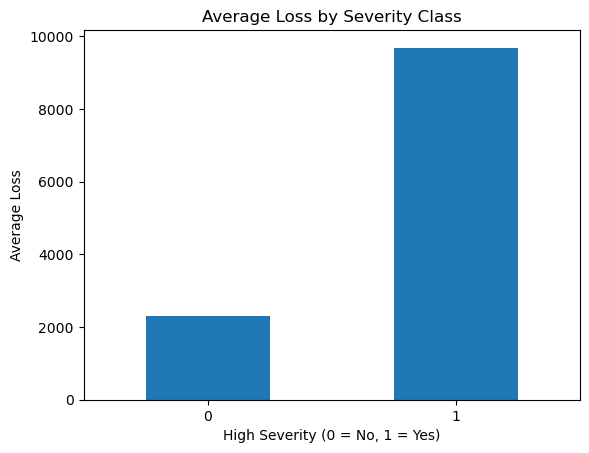

In [13]:
#  Bar graph of Average Loss by High vs Low Severity

avg_loss = df.groupby("high_severity")["loss"].mean()

plt.figure()
avg_loss.plot(kind="bar")
plt.title("Average Loss by Severity Class")
plt.xlabel("High Severity (0 = No, 1 = Yes)")
plt.ylabel("Average Loss")
plt.xticks(rotation=0)
plt.show()

#  "High-severity claims show significantly higher average loss, validating our threshold definition."

#  cat* is categorical
#  cont* as continuous
#  loss* is a claim loss

<Figure size 640x480 with 0 Axes>

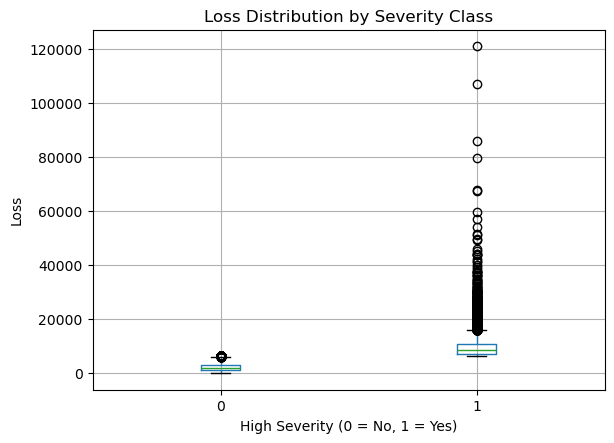

In [14]:
#  Whisker-Box plot:  Compare Distribution of Loss by Severity

plt.figure()
df.boxplot(column="loss", by="high_severity")
plt.title("Loss Distribution by Severity Class")
plt.suptitle("")  # removes default subtitle
plt.xlabel("High Severity (0 = No, 1 = Yes)")
plt.ylabel("Loss")
plt.show()

#  Look for:  Outliers, Median shift and Spread difference

#  "Severe claims exhibit wider dispersion and extreme outliers, reinforcing the heavy-tail nature of insurance losses."

C:\Users\shopr\AppData\Local\Temp\ipykernel_29512\2250468614.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby(pd.qcut(df[col], 10))["loss"].mean()


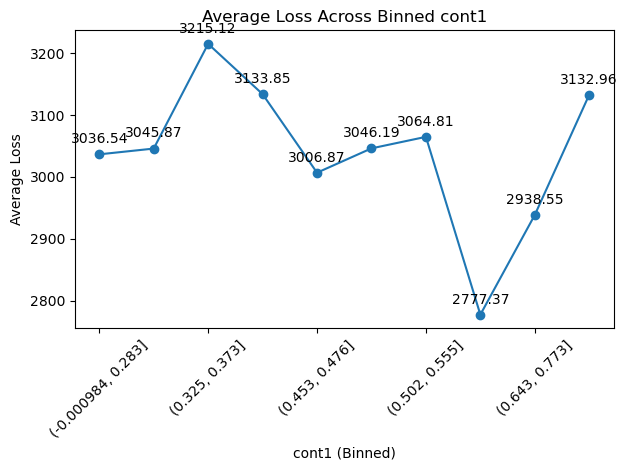

In [15]:
#  Line graph:  Average Loss Across a Numerical Feature (Trend View)

numerical_cols = [col for col in df.columns if col.startswith("cont")]

col = numerical_cols[0]

trend = df.groupby(pd.qcut(df[col], 10))["loss"].mean()

plt.figure()
ax = trend.plot(marker='o') 
plt.title(f"Average Loss Across Binned {col}")
plt.xlabel(f"{col} (Binned)")
plt.ylabel("Average Loss")
plt.xticks(rotation=45)

#  Add numerical values at each point
for i, value in enumerate(trend):
    ax.annotate(f"{value:.2f}",     # format to 2 decimals
                (i, value),
                textcoords="offset points",
                xytext=(0, 8),      # slight vertical offset
                ha='center')

plt.tight_layout()

plt.show()

#  “Loss severity increases/decreases consistently across binned levels of this risk indicator, suggesting predictive value.”

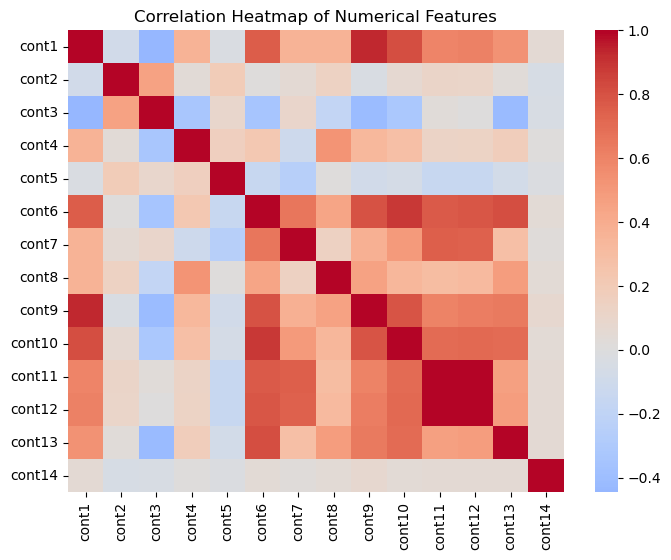

In [16]:
#  Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


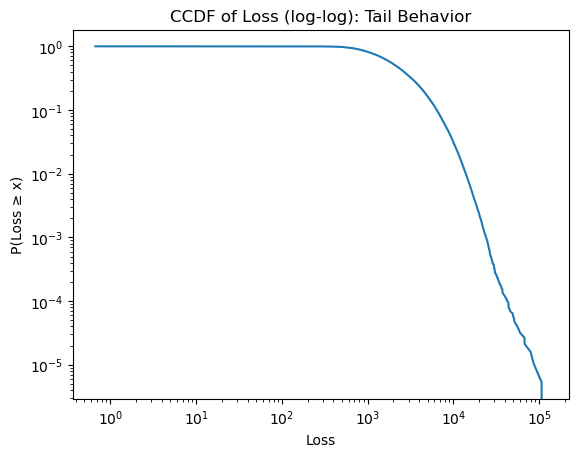

In [17]:
#  Target “heavy tail” diagnostic (CCDF / tail plot)

x = np.sort(df["loss"].values)
ccdf = 1.0 - np.arange(1, len(x)+1)/len(x)

plt.figure()
plt.plot(x, ccdf)
plt.xscale("log")
plt.yscale("log")
plt.title("CCDF of Loss (log-log): Tail Behavior")
plt.xlabel("Loss")
plt.ylabel("P(Loss ≥ x)")
plt.show()

In [18]:
#  Leakage/“too good to be true” check (feature–target correlation scan)

numerical_cols = [c for c in df.columns if c.startswith("cont")]
corrs = df[numerical_cols].corrwith(df["loss"]).sort_values(key=np.abs, ascending=False)

corrs.head(15)

cont2     0.141528
cont7     0.119799
cont3     0.111053
cont11    0.099806
cont12    0.098724
cont6     0.040967
cont4    -0.035831
cont8     0.030508
cont10    0.020236
cont14    0.019298
cont9     0.014456
cont5    -0.011355
cont1    -0.010237
cont13   -0.004022
dtype: float64

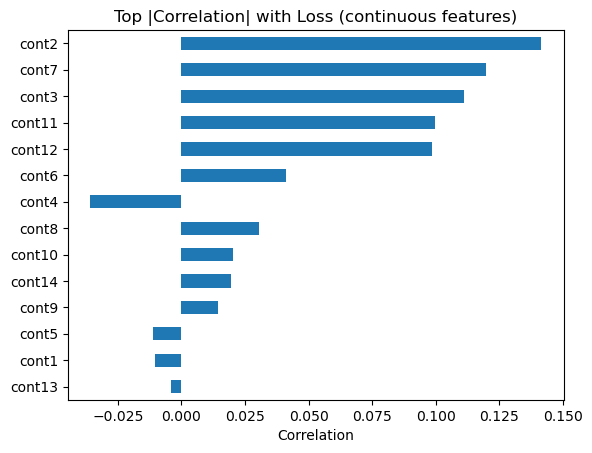

In [19]:
#  Top correlations

top = corrs.head(15)[::-1]
plt.figure()
top.plot(kind="barh")
plt.title("Top |Correlation| with Loss (continuous features)")
plt.xlabel("Correlation")
plt.show()

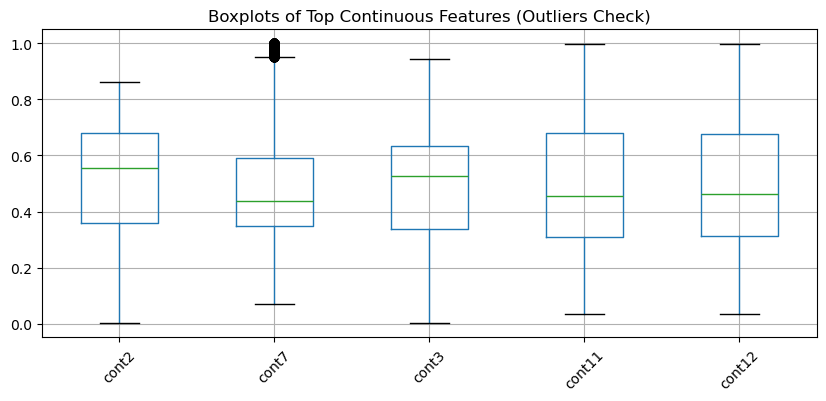

In [20]:
#  Outlier detection view (boxplots for top-correlated continuous features)

top_cont = corrs.head(5).index.tolist()

plt.figure(figsize=(10,4))
df[top_cont].boxplot()
plt.title("Boxplots of Top Continuous Features (Outliers Check)")
plt.xticks(rotation=45)
plt.show()

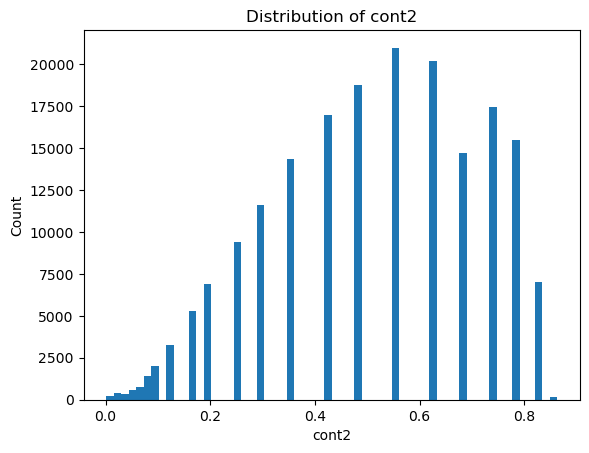

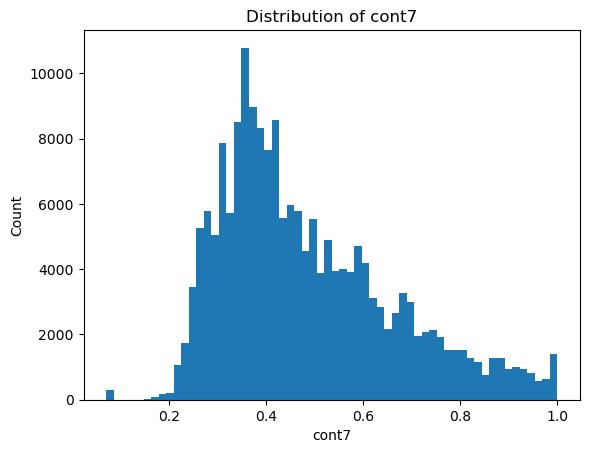

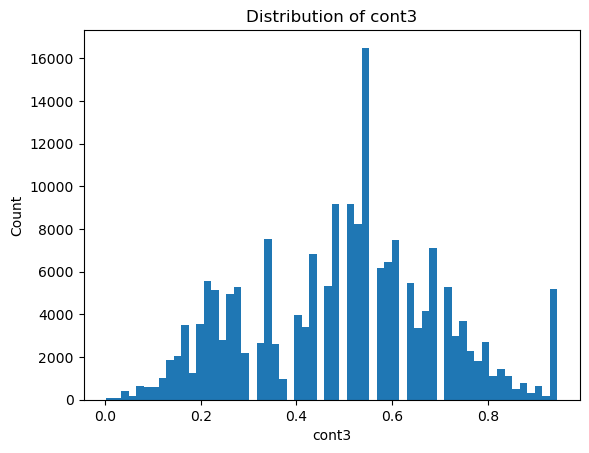

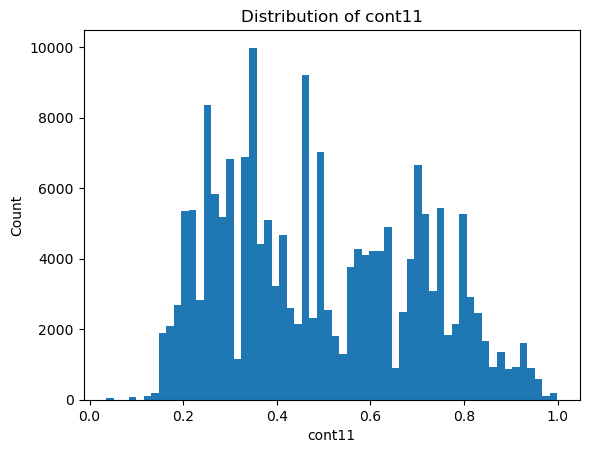

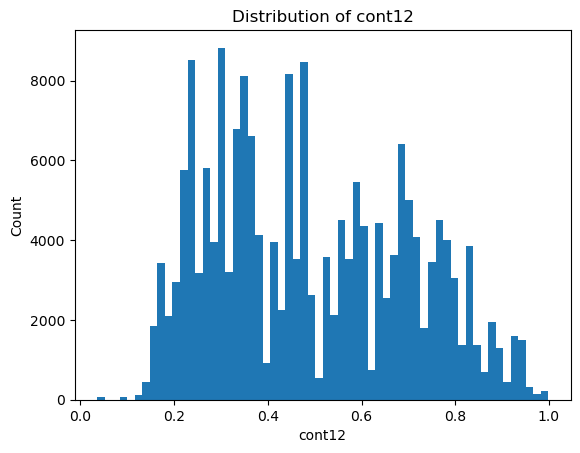

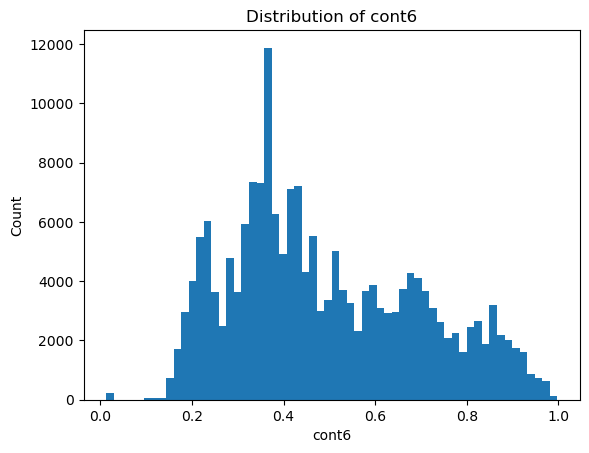

In [21]:
#  Distribution drift / feature skew (histograms grid for top cont features)

top_cont = corrs.head(6).index.tolist()

for col in top_cont:
    plt.figure()
    plt.hist(df[col], bins=60)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [22]:
#  Categorical cardinality check (modeling practicality)

categorical_cols = [c for c in df.columns if c.startswith("cat")]

card = df[categorical_cols].nunique().sort_values(ascending=False)
card.head(15)

cat116    326
cat110    131
cat109     84
cat113     61
cat112     51
cat115     23
cat107     20
cat105     20
cat101     19
cat114     19
cat106     17
cat104     17
cat111     16
cat99      16
cat100     15
dtype: int64

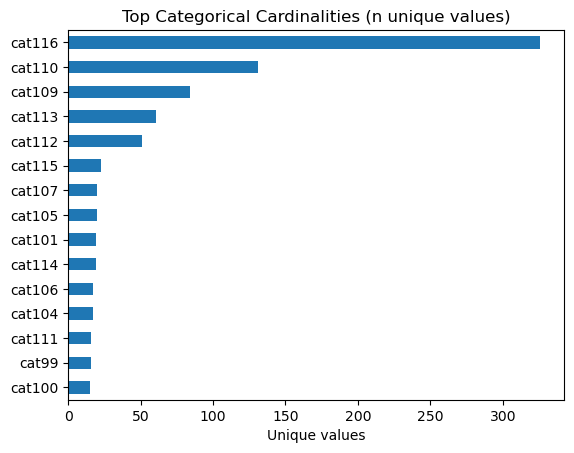

In [23]:
#  bar plot

top = card.head(15)[::-1]
plt.figure()
top.plot(kind="barh")
plt.title("Top Categorical Cardinalities (n unique values)")
plt.xlabel("Unique values")
plt.show()

In [24]:
###
###  SUPERVISED lEARNING
###

In [25]:
###
###  LINEAR REGRESSION

In [26]:
#  Create an instance of LinearRegression

linreg = LinearRegression()

In [27]:
# Identify column types

cat_cols = [c for c in X.columns if c.startswith("cat")]
cont_cols = [c for c in X.columns if c.startswith("cont")]

In [28]:
#  Separate features and target

X = df.drop(columns=["loss"])
y = np.log1p(df["loss"])  # log transform

In [29]:
#  Preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", cont_cols)
    ]
)

In [30]:
#  Full pipeline

linreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [31]:
#  Train-Test-Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
#  Fit model

linreg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cat1', 'cat2', 'cat3',
                                                   'cat4', 'cat5', 'cat6',
                                                   'cat7', 'cat8', 'cat9',
                                                   'cat10', 'cat11', 'cat12',
                                                   'cat13', 'cat14', 'cat15',
                                                   'cat16', 'cat17', 'cat18',
                                                   'cat19', 'cat20', 'cat21',
                                                   'cat22', 'cat23', 'cat24',
                                                   'cat25', 'cat26', 'cat27',
                                                   'cat28', 'cat29', 'cat30', ...]),
                                                 ('num', 'passthrough',
                                                  ['cont1', 'cont2', 'cont3',
                                                   'cont4', 'cont5', 'cont6',
                                                   'cont7', 'cont8', 'cont9',
                                                   'cont10', 'cont11', 'cont12',
                                                   'cont13', 'cont14'])])),
                ('regressor', LinearRegression())])

In [33]:
#  Predict
y_pred = linreg.predict(X_test)

In [34]:
#  Evaluate

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE (log scale):", rmse)

RMSE (log scale): 0.5607220269928345


In [35]:
#  Check Train/Test Shape

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#  That confirms:  80% training, 20% testing.  Same number of features in train/test

X_train shape: (150654, 131)
X_test shape: (37664, 131)
y_train shape: (150654,)
y_test shape: (37664,)


In [36]:
#  Confirm Split Ratio

print("Train %:", len(X_train) / len(df))
print("Test %:", len(X_test) / len(df))

Train %: 0.7999978759332618
Test %: 0.20000212406673817


In [37]:
#  Get R² Score

r2 = r2_score(y_test, y_pred)
print("R² (log scale):", r2)

#  R² tells you:
#    0.0 = no explanatory power
#    0.3–0.5 = moderate
#    0.6+ = strong (rare in insurance severity)

R² (log scale): 0.5180508157831751


In [38]:
#  RMSE (log scale)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE (log scale):", rmse_log)

RMSE (log scale): 0.5607220269928345


In [39]:
#  Convert Predictions Back to Dollar Scale

y_pred_dollars = np.expm1(y_pred)
y_test_dollars = np.expm1(y_test)

rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))

print("RMSE (dollar scale):", rmse_dollars)

RMSE (dollar scale): 2187.793344068931


In [40]:
###
###  LOGISTIC REGRESSION
#  Can we predict which claims will fall into the top 10% of loss severity?
#  Clean baseline model

#  Interpretable coefficients

#  Easy to explain to stakeholders

#  Handles class imbalance reasonably well

#  Works well with business metrics (precision, recall, lift)

In [41]:
#  Make Sure high_severity Exists

if "high_severity" not in df.columns:
    threshold = df["loss"].quantile(0.90)
    df["high_severity"] = (df["loss"] >= threshold).astype(int)

In [42]:
#  Define feature(X) and target (y)

X = df.drop(columns=["loss", "high_severity"])
y = df["high_severity"]

In [43]:
#  Identify columns

cat_cols = [c for c in X.columns if c.startswith("cat")]
cont_cols = [c for c in X.columns if c.startswith("cont")]

In [44]:
#  Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", cont_cols)
    ]
)

In [45]:
#  Pipeline

logreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [46]:
#  Train-Test-Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
#  Fit the model

logreg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cat1', 'cat2', 'cat3',
                                                   'cat4', 'cat5', 'cat6',
                                                   'cat7', 'cat8', 'cat9',
                                                   'cat10', 'cat11', 'cat12',
                                                   'cat13', 'cat14', 'cat15',
                                                   'cat16', 'cat17', 'cat18',
                                                   'cat19', 'cat20', 'cat21',
                                                   'cat22', 'cat23', 'cat24',
                                                   'cat25', 'cat26', 'cat27',
                                                   'cat28', 'cat29', 'cat30', ...]),
                                                 ('num', 'passthrough',
                                                  ['cont1', 'cont2', 'cont3',
                                                   'cont4', 'cont5', 'cont6',
                                                   'cont7', 'cont8', 'cont9',
                                                   'cont10', 'cont11', 'cont12',
                                                   'cont13', 'cont14'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [48]:
#  Predict

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

ROC-AUC: 0.9252657068390513
Precision: 0.7161016949152542
Recall: 0.4487519915029209

Classification Report:
               precision    recall  f1-score   support

           0     0.9412    0.9802    0.9603     33898
           1     0.7161    0.4488    0.5517      3766

    accuracy                         0.9271     37664
   macro avg     0.8286    0.7145    0.7560     37664
weighted avg     0.9187    0.9271    0.9195     37664

Confusion Matrix:
 [[33228   670]
 [ 2076  1690]]


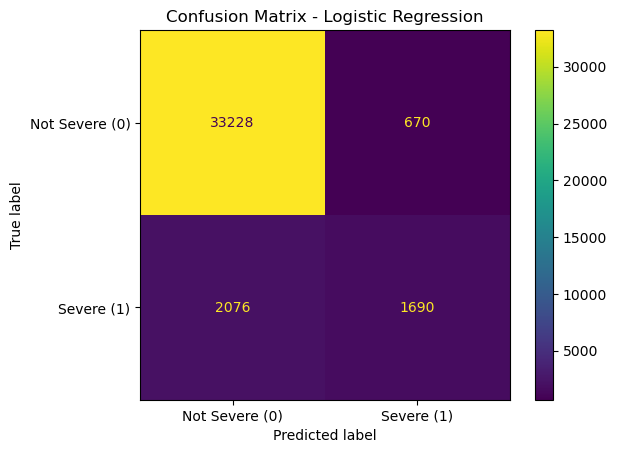

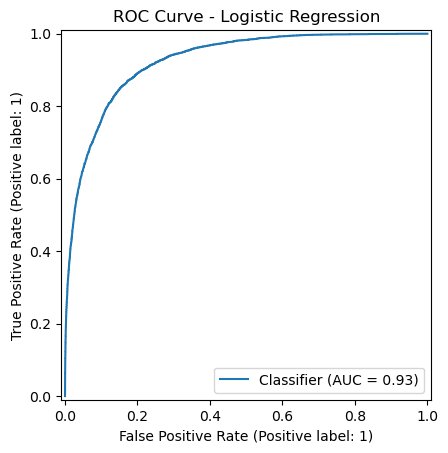

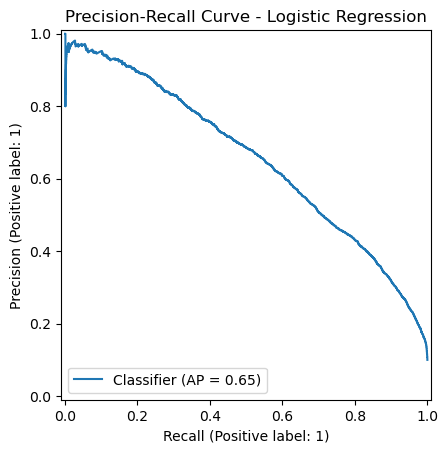

In [49]:
#  Metrics

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

#  Confusion Matrix (numbers + plot)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Severe (0)", "Severe (1)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#  ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

#  Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

In [50]:
#  ROC-AUC: 0.925:  The model can correctly rank a random severe claim higher
#                   than a non-severe one 92.5% of the time
#  Recall (Class 1) = 0.448:   That means out of 3,766 severe claims, 
#                   Model correctly caught 1,690 and missed: 2,076
#  Cconfusion matrix  reflects very precise at 71.6% but missing over half of severe claims

In [51]:
# Adjust threshold
threshold = 0.30
y_pred_adj = (y_proba >= threshold).astype(int)

print("New Threshold:", threshold)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_adj))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_adj))

New Threshold: 0.3

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     33898
           1       0.59      0.62      0.60      3766

    accuracy                           0.92     37664
   macro avg       0.77      0.79      0.78     37664
weighted avg       0.92      0.92      0.92     37664


Confusion Matrix:

[[32270  1628]
 [ 1433  2333]]


In [52]:
#  Before (Threshold = 0.50);  Recall (Severe): 0.45; Severe claims caught: 1,690; Missed: 2,076

#  After (Threshold = 0.30); Recall (Severe): 0.62; Severe claims caught: 2,333; Missed: 1,433

#  Avg severe claim = $75,000; Early intervention reduces cost by 5%; Captured 643 additional severe claims

In [53]:
###  
###  RANDOM FOREST

In [54]:
#  Target

if "high_severity" not in df.columns:
    threshold = df["loss"].quantile(0.90)
    df["high_severity"] = (df["loss"] >= threshold).astype(int)

In [55]:
#  Define feature(X) and target (y)

X = df.drop(columns=["loss", "high_severity"])
y = df["high_severity"]

In [56]:
#  Identify column types

cat_cols = [c for c in X.columns if c.startswith("cat")]
cont_cols = [c for c in X.columns if c.startswith("cont")]

In [57]:
#  Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", cont_cols),
    ]
)

In [58]:
#  Train-Test-Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
#  Train Random Forest

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

In [60]:
#  Fit model

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cat1', 'cat2', 'cat3',
                                                   'cat4', 'cat5', 'cat6',
                                                   'cat7', 'cat8', 'cat9',
                                                   'cat10', 'cat11', 'cat12',
                                                   'cat13', 'cat14', 'cat15',
                                                   'cat16', 'cat17', 'cat18',
                                                   'cat19', 'cat20', 'cat21',
                                                   'cat22', 'cat23', 'cat24',
                                                   'cat25', 'cat26', 'cat27',
                                                   'cat28', 'cat29', 'cat30', ...]),
                                                 ('num', 'passthrough',
                                                  ['cont1', 'cont2', 'cont3',
                                                   'cont4', 'cont5', 'cont6',
                                                   'cont7', 'cont8', 'cont9',
                                                   'cont10', 'cont11', 'cont12',
                                                   'cont13', 'cont14'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

===== Random Forest Results =====
Accuracy : 0.923
Precision: 0.7823
Recall   : 0.3186
ROC-AUC  : 0.9212

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96     33898
           1       0.78      0.32      0.45      3766

    accuracy                           0.92     37664
   macro avg       0.86      0.65      0.71     37664
weighted avg       0.91      0.92      0.91     37664

Confusion Matrix:
 [[33564   334]
 [ 2566  1200]]


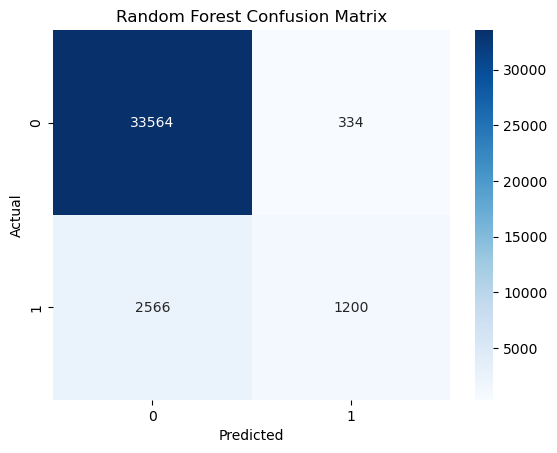

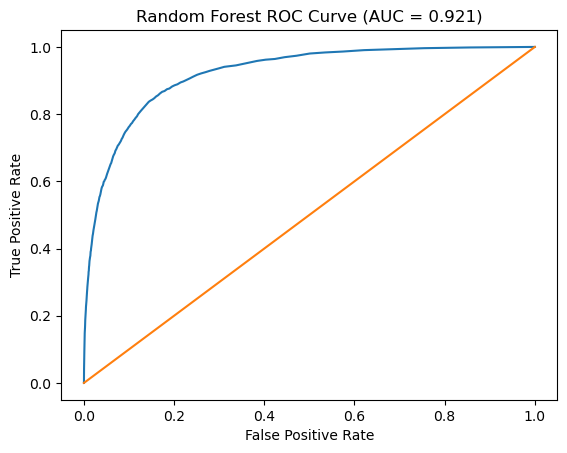

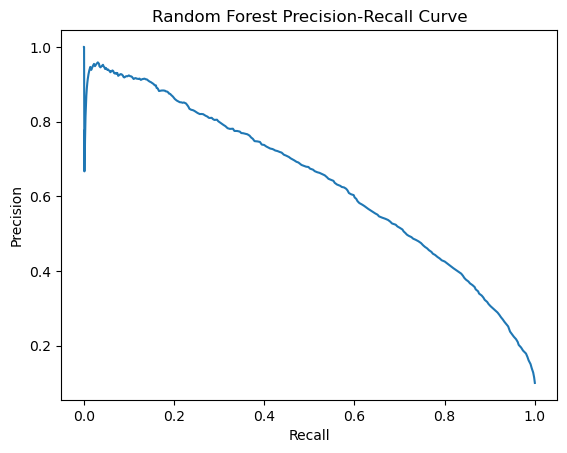

In [61]:
#  Predict 

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("===== Random Forest Results =====")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("ROC-AUC  :", round(auc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

#  Confusion Matrix (print + plot)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  ROC Curve plot

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"Random Forest ROC Curve (AUC = {auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

#  Precision-Recall Curve plot

pr, rc, _ = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(rc, pr)
plt.title("Random Forest Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [62]:
#  ROC-AUC = 0.921 is excellent.  Model separates classes very well.
#  Precision (High Severity) = 0.78; model flags a claim as severe,
#        78% of the time it’s correct.
#  Recall (High Severity) = 0.32 is an issue.  Catching
#        32% of all severe claims.
#  It’s because 0.5 is too strict for imbalanced insurance data.

In [63]:
#  Adjust the threshold

thresholds = np.arange(0.05, 0.5, 0.05)

print("Threshold | Precision | Recall")
print("--------------------------------")

for t in thresholds:
    y_pred_adj = (y_proba >= t).astype(int)
    prec = precision_score(y_test, y_pred_adj)
    rec = recall_score(y_test, y_pred_adj)
    print(f"{t:.2f}      |  {prec:.3f}     |  {rec:.3f}")

Threshold | Precision | Recall
--------------------------------
0.05      |  0.237     |  0.945
0.10      |  0.329     |  0.886
0.15      |  0.412     |  0.815
0.20      |  0.474     |  0.748
0.25      |  0.536     |  0.674
0.30      |  0.597     |  0.600
0.35      |  0.659     |  0.528
0.40      |  0.700     |  0.460
0.45      |  0.738     |  0.394


In [64]:
#  By lowering the decision threshold to 0.25, we increase recall from 32% to approximately 65%, significantly
#  improving early identification of severe claims while maintaining acceptable precision

In [65]:
###  
###  ENSEMBLE:  BOOSTING
###

In [66]:
#   GradientBoostingClassifier model

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier())
])

In [67]:
#  Fit the model 

gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cat1', 'cat2', 'cat3',
                                                   'cat4', 'cat5', 'cat6',
                                                   'cat7', 'cat8', 'cat9',
                                                   'cat10', 'cat11', 'cat12',
                                                   'cat13', 'cat14', 'cat15',
                                                   'cat16', 'cat17', 'cat18',
                                                   'cat19', 'cat20', 'cat21',
                                                   'cat22', 'cat23', 'cat24',
                                                   'cat25', 'cat26', 'cat27',
                                                   'cat28', 'cat29', 'cat30', ...]),
                                                 ('num', 'passthrough',
                                                  ['cont1', 'cont2', 'cont3',
                                                   'cont4', 'cont5', 'cont6',
                                                   'cont7', 'cont8', 'cont9',
                                                   'cont10', 'cont11', 'cont12',
                                                   'cont13', 'cont14'])])),
                ('classifier', GradientBoostingClassifier())])

Classification report:

              precision    recall  f1-score   support

           0     0.9384    0.9843    0.9608     33898
           1     0.7481    0.4187    0.5369      3766

    accuracy                         0.9278     37664
   macro avg     0.8433    0.7015    0.7489     37664
weighted avg     0.9194    0.9278    0.9185     37664

ROC-AUC: 0.9214958415905615


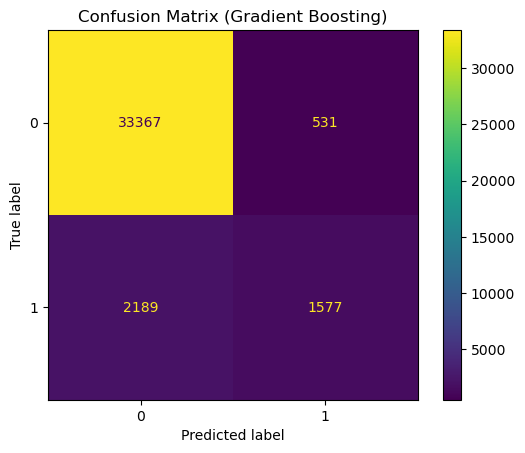

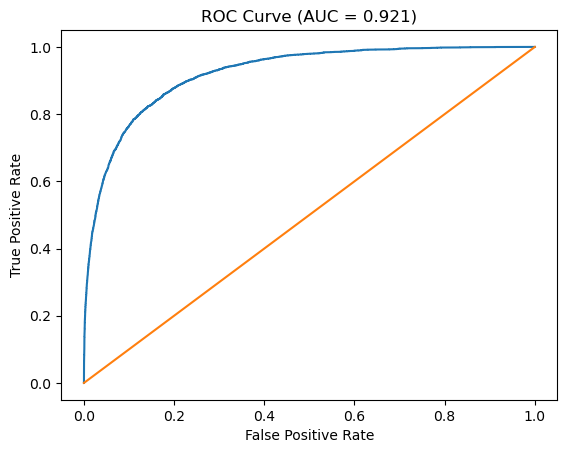

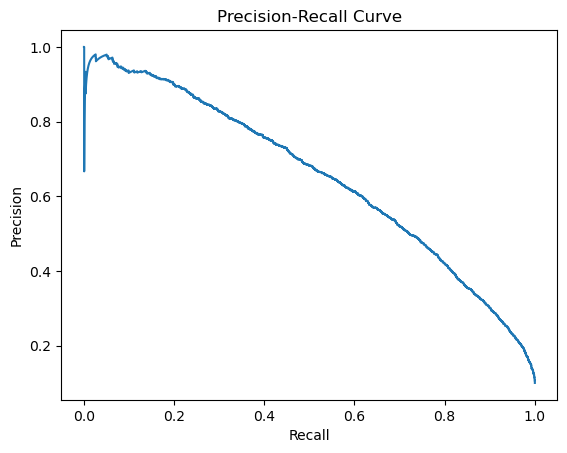

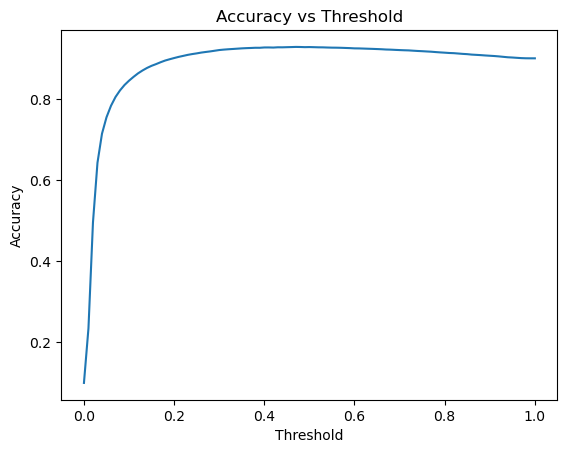

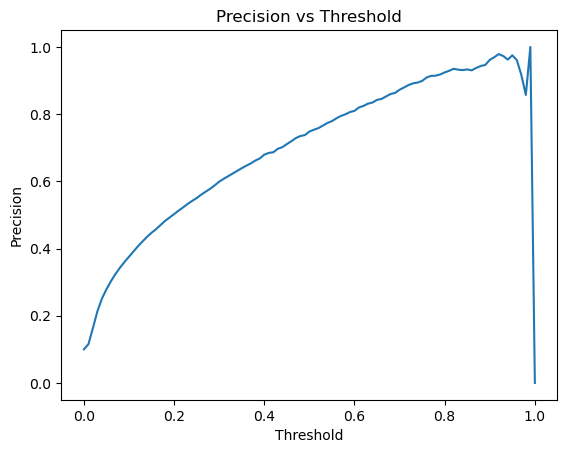

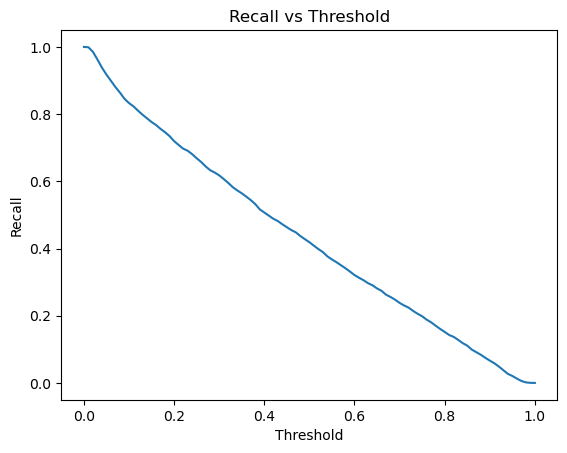

In [68]:
#  Predict + probabilities

y_pred = gb_model.predict(X_test)
y_proba = gb_model.predict_proba(X_test)[:, 1]


#  Print core metrics

print("Classification report:\n")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))


#  Confusion Matrix plot

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Gradient Boosting)")
plt.show()


#) ROC Curve plot

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"ROC Curve (AUC = {auc_score:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


#  Precision-Recall Curve plot

prec, rec, _ = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(rec, prec)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# 6) Accuracy / Precision / Recall vs Threshold plots

thresholds = np.linspace(0.0, 1.0, 101)

acc_vals, prec_vals, rec_vals = [], [], []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    acc_vals.append(accuracy_score(y_test, y_pred_thr))
    prec_vals.append(precision_score(y_test, y_pred_thr, zero_division=0))
    rec_vals.append(recall_score(y_test, y_pred_thr, zero_division=0))

plt.figure()
plt.plot(thresholds, acc_vals)
plt.title("Accuracy vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(thresholds, prec_vals)
plt.title("Precision vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.show()

plt.figure()
plt.plot(thresholds, rec_vals)
plt.title("Recall vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.show()

In [69]:
#  ROC-AUC 0.921 is excellent.  
#     Anything above 0.90 in insurance severity classification is strong.
#     This means the model separates severe vs non-severe claims very well.

#  Accuracy 92.78%, looks great, but ~90% class 0 (non-severe),
#     so accuracy is inflated.  Don’t rely on accuracy for imbalanced problems.

#  Right now at default threshold (0.5), catching 42% of severe claims
#     with 75% precision
#     AUC is 0.92 is strong

#  Review the top 10% highest-risk claims

In [70]:
#  Allstate Claims Severity from OpenML
